In [ ]:
!pip install -q kaggle

In [ ]:
import os
from google.colab import userdata

os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")

print("Kaggle credentials loaded successfully.")

Kaggle credentials loaded successfully.


First, let's create the target directory `/content/data` and then download the `microsoft-catsvsdogs-dataset` from Kaggle using the Kaggle API. We will place the downloaded zip file directly into the `/content/data` directory.

In [ ]:
!mkdir -p /content/data
!kaggle datasets download -d shaunthesheep/microsoft-catsvsdogs-dataset -p /content/data

Dataset URL: https://www.kaggle.com/datasets/shaunthesheep/microsoft-catsvsdogs-dataset
License(s): other
100% 788M/788M [00:37<00:00, 22.2MB/s]



In [ ]:
import os

# Create the directory if it doesn't exist
os.makedirs('/content/data', exist_ok=True)

# Download the dataset from Kaggle into the /content/data directory
!kaggle datasets download -d tongpython/cat-and-dog -p /content/data

Dataset URL: https://www.kaggle.com/datasets/tongpython/cat-and-dog
License(s): CC0-1.0
100% 218M/218M [00:09<00:00, 23.0MB/s]



In [ ]:
import zipfile
import os

zip_path = "/content/data/microsoft-catsvsdogs-dataset.zip"
extract_path = "/content/data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully.")

Dataset extracted successfully.


In [ ]:
base_dir = "/content/data/PetImages"


print("Available folders:", os.listdir(base_dir))
print("Cat images:", len(os.listdir(os.path.join(base_dir, "Cat"))))
print("Dog images:", len(os.listdir(os.path.join(base_dir, "Dog"))))

Available folders: ['Cat', 'Dog']
Cat images: 12501
Dog images: 12501


In [ ]:
from PIL import Image

classes = ["Cat", "Dog"]
removed = 0

for class_name in classes:
    folder_path = os.path.join(base_dir, class_name)

    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)

        try:
            img = Image.open(img_path)
            img.verify()
        except Exception:
            os.remove(img_path)
            removed += 1

print("Corrupted images removed:", removed)

Corrupted images removed: 4


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 150
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,

    # Overfitting reduction through augmentation
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    base_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training",
    shuffle=True
)

val_data = val_datagen.flow_from_directory(
    base_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation",
    shuffle=False
)

print("Class labels:", train_data.class_indices)

Found 20000 images belonging to 2 classes.
Found 4998 images belonging to 2 classes.
Class labels: {'Cat': 0, 'Dog': 1}


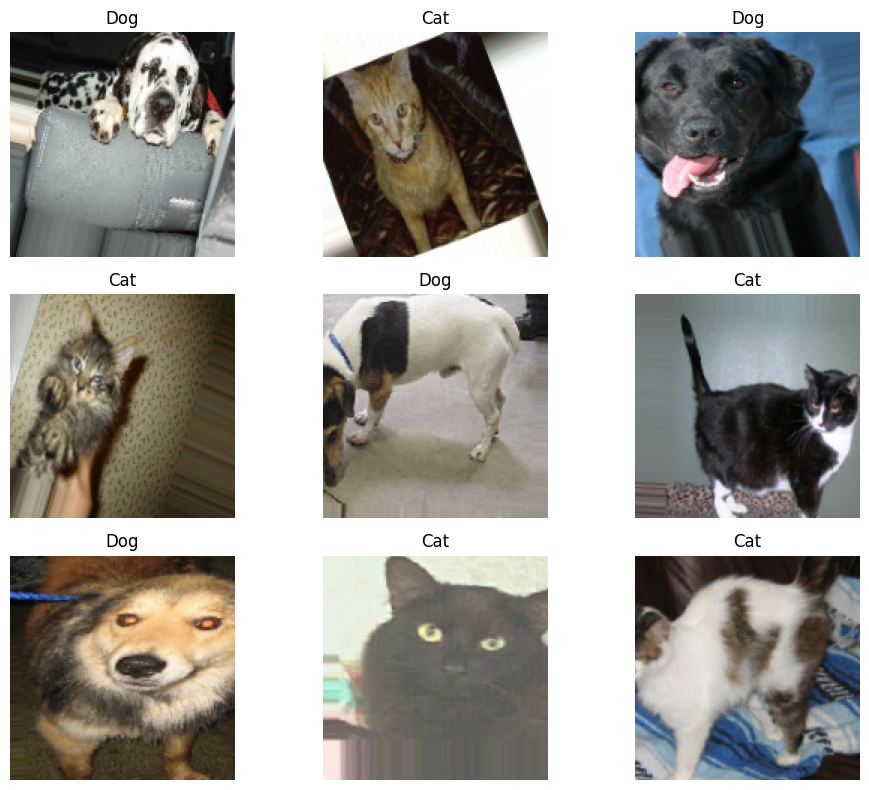

In [ ]:
import matplotlib.pyplot as plt

images, labels = next(train_data)

plt.figure(figsize=(10, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title("Dog" if labels[i] == 1 else "Cat")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.regularizers import l2

model = Sequential([
    Conv2D(
        32, (3, 3), activation="relu", padding="same",
        kernel_regularizer=l2(0.001),
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    ),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    Conv2D(
        64, (3, 3), activation="relu", padding="same",
        kernel_regularizer=l2(0.001)
    ),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.30),

    Conv2D(
        128, (3, 3), activation="relu", padding="same",
        kernel_regularizer=l2(0.001)
    ),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.35),

    Conv2D(
        256, (3, 3), activation="relu", padding="same",
        kernel_regularizer=l2(0.001)
    ),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.40),

    GlobalAveragePooling2D(),

    Dense(128, activation="relu", kernel_regularizer=l2(0.001)),
    Dropout(0.25),
    Dense(64, activation="relu", kernel_regularizer=l2(0.001)),
    Dropout(0.25),


    Dense(1, activation="sigmoid")
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 18, 18, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 431,553 (1.65 MB)

 Trainable params: 430,593 (1.64 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-7
    ),

    ModelCheckpoint(
        "/content/best_cat_dog_basic_cnn_overfitting_solution.h5",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max"
    )
]

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
563/625 ━━━━━━━━━━━━━━━━━━━━ 3:17 3s/step - accuracy: 0.5721 - loss: 1.2334

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5745 - loss: 1.2292

625/625 ━━━━━━━━━━━━━━━━━━━━ 2117s 3s/step - accuracy: 0.5971 - loss: 1.1890 - val_accuracy: 0.6345 - val_loss: 1.1273 - learning_rate: 1.0000e-04
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6206 - loss: 1.1228

625/625 ━━━━━━━━━━━━━━━━━━━━ 2110s 3s/step - accuracy: 0.6273 - loss: 1.1059 - val_accuracy: 0.6757 - val_loss: 1.0365 - learning_rate: 1.0000e-04
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2093s 3s/step - accuracy: 0.6578 - loss: 1.0363 - val_accuracy: 0.6731 - val_loss: 0.9917 - learning_rate: 1.0000e-04
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6859 - loss: 0.9835

625/625 ━━━━━━━━━━━━━━━━━━━━ 2075s 3s/step - accuracy: 0.6928 - loss: 0.9650 - val_accuracy: 0.6941 - val_loss: 0.9934 - learning_rate: 1.0000e-04
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7064 - loss: 0.9225

625/625 ━━━━━━━━━━━━━━━━━━━━ 2066s 3s/step - accuracy: 0.7068 - loss: 0.9139 - val_accuracy: 0.7165 - val_loss: 0.9082 - learning_rate: 1.0000e-04
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2107s 3s/step - accuracy: 0.7208 - loss: 0.8605 - val_accuracy: 0.6847 - val_loss: 1.0930 - learning_rate: 1.0000e-04
Epoch 7/20
 11/625 ━━━━━━━━━━━━━━━━━━━━ 33:44 3s/step - accuracy: 0.7063 - loss: 0.8629